![Colegio Bourbaki](https://github.com/contepablod/ML_Bourbaki/blob/master/Semana3/Images/Bourbaki.png?raw=1)

### Sistemas de recomendación

En este ejemplo los datos de la competencia de Netflix puesta en Kaggle. (https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data)

#### Contexto

Netflix convocó el concurso abierto Netflix Prize para encontrar el mejor algoritmo que predijera las valoraciones de los usuarios sobre las películas. El gran premio, dotado con 1.000.000 de dólares, lo ganó el equipo Pragmatic Chaos de BellKor. Este es el conjunto de datos que se utilizó en esa competición.

### Objetivo

El objetivo de esta competencia era mejorar el algoritmo de recomendación 10%. No buscaremos eso por cuestiones de tiempo. Sin embargo, los objetivos de esta notebook son:

* Análisis exploratorio de matriz y por qué es dispersa.
* Implementación de Singular Value Decomposition.
* Implementación de un modelo de sistema de recomendación de filtro colaborativo.



### Librerias

In [1]:
!pip install surprise

In [2]:
# Data Analysis
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Recommendation System
from surprise import (
    Reader,
    Dataset,
    SVD,
    SVDpp,
)  # Simple Python RecommendatIon System Engine
from surprise.model_selection import cross_validate

**Surprise:**

Surprise es una libreria de Python hecha sobre scikit-learn para construir y analizar sistemas de recomendación basados en factorización matricial,proporcionando herramientas para evaluar, analizar y comparar el rendimiento de los algoritmos. Los procedimientos de validación cruzada pueden ejecutarse muy fácilmente utilizando potentes iteradores CV (inspirados en las excelentes herramientas de scikit-learn), así como la búsqueda exhaustiva sobre un conjunto de parámetros.

El nombre SurPRISE (más o menos :) significa Simple Python RecommendatIon System Engine.

Surprise no admite valoraciones implícitas ni información basada en el contenido.

Mas información:
* https://surpriselib.com/

### Carga de datos

En este caso cargar los datos nos llevará un rato por la gran cantidad de registros que tenemos. Sólo cargaremos un archivo, pero la competencia tiene un total de 4 archivos.

In [3]:
import numpy as np
import pandas as pd

In [4]:
pd.__version__


'2.2.2'

In [5]:
df1 = pd.read_csv(
    "/content/combined_data_1.txt",
    usecols=[0,1],
    header=None,
    names=["CostumerID", "Rating"],
    low_memory=True,
)

In [6]:
df1.head()

,CostumerID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


### Analisis exploratorio

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column      Dtype  
---  ------      -----  
 0   CostumerID  object 
 1   Rating      float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


Veamos la presencia de datos nulos:

In [8]:
df1.isna().sum()

,0
CostumerID,0
Rating,4499


En este caso los registros que tenemos con valores nulos corresponden al Id de las películas. Si observamos los registros nulos están ordenados del 1 al 4,499

In [9]:
# Identificar las filas que contienen el ID de la película
# Son aquellas donde el 'Rating' es NaN
filas_pelicula = df1["Rating"].isna()
df1[filas_pelicula]

,CostumerID,Rating
0,1:,NaN
548,2:,NaN
694,3:,NaN
2707,4:,NaN
2850,5:,NaN
...,...,...
24046714,4495:,NaN
24047329,4496:,NaN
24056849,4497:,NaN
24057564,4498:,NaN


In [10]:
# Creamos la columna y le asignamos el ID (quitando los dos puntos) solo en las filas correspondientes
df1.loc[filas_pelicula, 'MovieID'] = df1.loc[filas_pelicula, 'CostumerID'].str.replace(':', '')

# ffill() propaga el último valor no nulo hacia abajo, asignando el ID a todos los ratings de esa película
df1['MovieID'] = df1['MovieID'].ffill()


# Filtramos para eliminar las filas originales que solo tenían el ID de la película
df1 = df1[~filas_pelicula].reset_index(drop=True)

#Optimización extrema de memoria (Esencial para archivos masivos)
# combined_data1.txt llega hasta el MovieID 4499, int16 soporta hasta 32,767 (int32 por seguridad si luego decidimos incluir los otros archivos)
df1['MovieID'] = df1['MovieID'].astype(np.int32)

# Los CustomerID tienen 7 dígitos, int32 soporta hasta 2 mil millones
df1['CostumerID'] = df1['CostumerID'].astype(np.int32)

# Los ratings son de 1 a 5, int8 es perfecto (soporta hasta 127)
df1['Rating'] = df1['Rating'].astype(np.int8)




In [11]:
df1

,CostumerID,Rating,MovieID
0,1488844,3,1
1,822109,5,1
2,885013,4,1
3,30878,4,1
4,823519,3,1
...,...,...,...
24053759,2591364,2,4499
24053760,1791000,2,4499
24053761,512536,5,4499
24053762,988963,3,4499


In [12]:

print(f"Este es el número de películas que tenemos en este archivo: {df1['MovieID'].nunique()}")

Este es el número de películas que tenemos en este archivo: 4499


In [13]:
reviews = df1["Rating"].count()
print(f"Este es el número de calificaciones: {reviews}")

Este es el número de calificaciones: 24053764


In [14]:
users = df1["CostumerID"].nunique()
print(f"Esta es la cantidad de usuarios que tenemos: {users}")

Esta es la cantidad de usuarios que tenemos: 470758


En este caso no estaremos trabajando con las fechas. Por lo tanto haremos un subconjunto de nuestro DF original.

Ahora observemos como se distribuye la frecuencia para la columna de rating.

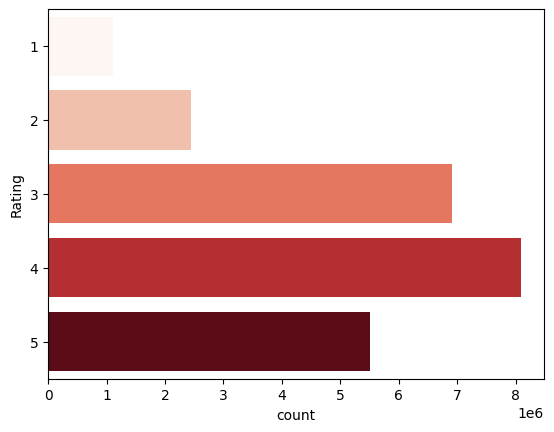

In [15]:
sns.countplot(
    y=df1["Rating"], orient="v", hue=df1["Rating"], palette="Reds", legend=False
)
plt.show()

In [16]:
df1["Rating"].value_counts() / df1["Rating"].count() * 100

,count
Rating,
4,33.615284
3,28.703121
5,22.892812
2,10.140089
1,4.648694


La mayor parte de nuestros valores se distribuyen en los ratings de 3 y 4 estrellas. La mayoría de los rating son positivos.

#### Reducir la cantidad de datos

Nuestros datos se encuentran en el formato correcto. Sin embargo, existen muchos datos que no ayudan a nuestra predicción. ¿Por qué sucede esto? En esto momento no parece que tenemos valores nulos, sin embargo no todos los usuarios han calificado las 4,499 películas que tenemos. **De aquí va a provenir nuestra matriz dispersa**.

Pero antes de pasar a la matriz intentemos reducir la cantidad de datos que tenemos removiendo dos casos de nuestro dataset:

1) Las películas que tiene pocas calificaciones.
2) Usuarios que han calificado muy pocas películas.



In [19]:
# Agregamos a nivel película para revisar el conteo y valor promedio para cada una.
movie_agg = df1.groupby("MovieID").agg({"Rating": ["count", "mean"]})
movie_agg.sort_values(by=("Rating", "count"), ascending=False)

Rating          
          count      mean
MovieID                  
1905     193941  4.153908
2152     162597  3.425322
3860     160454  3.434517
4432     156183  3.755364
571      154832  3.962585
...         ...       ...
4294         44  4.272727
915          43  2.837209
3656         42  3.214286
4338         39  2.948718
4362         36  2.000000

[4499 rows x 2 columns]

In [21]:
movie_agg.describe()

Rating             
               count         mean
count    4499.000000  4499.000000
mean     5346.468993     3.221945
std     16176.313851     0.526276
min        36.000000     1.287879
25%       192.000000     2.886389
50%       552.000000     3.244792
75%      2538.000000     3.598769
max    193941.000000     4.670989

Observamos el comportamiento de la distribución del conteo.

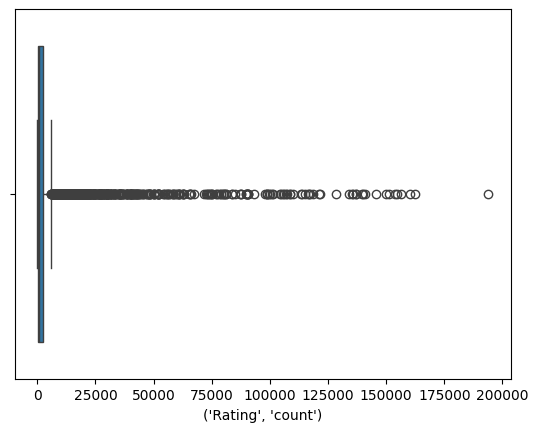

In [22]:
sns.boxplot(x=movie_agg[("Rating", "count")])
plt.show()

Por el comportamiento de la distribución del conteo de nuestros ratings observamos que hay un número considerable de películas con un muy pocas calificaciones. Revisemos cuántas son.

In [24]:
# Tomamos el valor del tercer cuartil.
movies_low_rating = movie_agg[("Rating", "count")].quantile(0.75)
movies_low_rating

np.float64(2538.0)

In [25]:
# Seleccionamos todas las películas que están por debajo del valor del cuartil
movies_to_drop = movie_agg[movie_agg[("Rating", "count")] < movies_low_rating].index
movies_to_drop.shape

(3374,)

Ahora observemos el caso del conteo para los usuarios.

In [31]:
user_agg = df1.groupby("CostumerID").agg({"Rating": ["count", "mean"]})["Rating"]
user_agg.sort_values(by="count", ascending=False)

,count,mean
CostumerID,,
305344,4467,1.894784
387418,4422,1.827001
2439493,4195,1.185459
1664010,4019,4.255785
2118461,3769,4.083311
...,...,...
2563315,1,5.000000
2563528,1,4.000000
1221453,1,3.000000


In [32]:
user_agg.describe()

,count,mean
count,470758.000000,470758.000000
mean,51.095816,3.678843
std,74.405055,0.564863
min,1.000000,1.000000
25%,8.000000,3.347826
50%,24.000000,3.682540
75%,64.000000,4.000000
max,4467.000000,5.000000


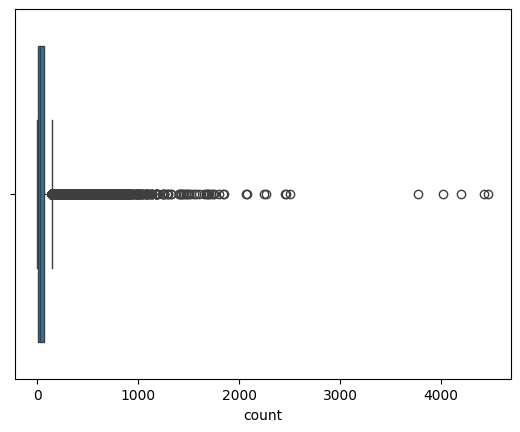

In [33]:
sns.boxplot(x=user_agg["count"])
plt.show()

In [37]:
user_low_rating = user_agg["count"].quantile(0.75)
user_low_rating

np.float64(64.0)

In [38]:
users_to_drop = user_agg[user_agg["count"] < user_low_rating].index
users_to_drop.shape

(351840,)

Removamos las películas con bajo número de calificaciones tanto los usuarios con pocas películas calificadas.

In [39]:
df1_trim = df1[~df1["MovieID"].isin(movies_to_drop)]

In [40]:
df1.shape, df1_trim.shape

((24053764, 3), (22144631, 3))

In [41]:
df1_trim = df1_trim[~df1["CostumerID"].isin(users_to_drop)]

/tmp/ipykernel_38954/1978083858.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1_trim = df1_trim[~df1["CostumerID"].isin(users_to_drop)]


In [42]:
df1.shape, df1_trim.shape

((24053764, 3), (15622656, 3))

In [43]:
df1_trim.shape[0] / df1.shape[0]

0.6494890363104918

Eliminamos el 30% de nuestros datos.

### Preparación de los datos

Vamos a convertir los datos en una matriz de valoración.

In [44]:
pivot_user_item = df1_trim.pivot(
    index="CostumerID", columns="MovieID", values="Rating"
).fillna(0)

In [45]:
pivot_user_item

MovieID,8,16,17,18,26,28,30,33,44,45,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
CostumerID,,,,,,,,,,,,,,,,,,,,,
6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,5.0,0.0,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,...,3.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
79,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
134,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2649336,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
2649370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2649378,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Factorización de Matrices: Singular Value Decomposion.

SVD (Descomposición en Valores Singulares, por sus siglas en inglés) es una técnica de factorización de matrices que descompone una matriz en tres matrices más simples: una matriz de izquierda singular, una matriz diagonal singular y una matriz de derecha singular.

La descomposición en valores singulares es ampliamente utilizada en diversas áreas, incluyendo procesamiento de señales, procesamiento de imágenes, aprendizaje automático y **sistemas de recomendación**. En el contexto de sistemas de recomendación, la SVD se utiliza comúnmente para realizar factorización de matrices en el ámbito de la recomendación colaborativa.

La idea central detrás de la SVD es encontrar una representación latente de los datos, donde cada ítem y cada usuario están descritos por un conjunto de características (vectores de factores latentes). Al descomponer la matriz original en matrices de características, es posible aproximar la matriz original al multiplicar estas matrices de características.

En sistemas de recomendación, la SVD se utiliza para predecir las calificaciones de los usuarios para elementos que aún no han sido calificados, basándose en las características latentes aprendidas. Sin embargo, **es importante tener en cuenta que la SVD puede sufrir de problemas de escalabilidad y manejo de datos dispersos**, lo que ha llevado al desarrollo de variantes como SVD truncada y métodos de factorización de matrices más avanzados en sistemas de recomendación modernos.

In [46]:
df1_trim.head()

,CostumerID,Rating,MovieID
5098,824097,2,8
5101,785314,1,8
5102,243963,3,8
5104,1447783,4,8
5108,1912665,1,8


In [47]:
df1_trim.shape

(15622656, 3)

In [48]:
# Utilizamos las clases y funciones que importamos del módulo surprise (Reader, Dataset, SVD)
reader = Reader()
data = Dataset.load_from_df(
    df1_trim[["CostumerID", "MovieID", "Rating"]][:100_000], reader
)  # ,
# reader) # Es necesario pasar en este orden las columnas

# Perform cross-validation with additional metrics
metrics = ["rmse", "mae"]

svd = SVD(n_epochs=100, lr_all=0.00001, reg_all=0.0001, random_state=42)
cross_validate(svd, data, measures=metrics, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9852  0.9904  0.9890  0.9937  0.9874  0.9891  0.0029  
MAE (testset)     0.7918  0.7955  0.7964  0.7991  0.7982  0.7962  0.0025  
Fit time          6.93    5.97    6.85    7.06    6.39    6.64    0.40    
Test time         0.11    0.75    0.10    0.18    0.36    0.30    0.25    


{'test_rmse': array([0.98519604, 0.99041593, 0.9890057 , 0.99374504, 0.9873592 ]),
 'test_mae': array([0.79182004, 0.79548882, 0.79644498, 0.79913175, 0.79822442]),
 'fit_time': (6.926293611526489,
  5.96782374382019,
  6.849719285964966,
  7.062223196029663,
  6.390978097915649),
 'test_time': (0.11390519142150879,
  0.7534451484680176,
  0.09528851509094238,
  0.17743229866027832,
  0.3599710464477539)}

Ahora ya tenemos nuestra matriz factorizada y lista para generar recomendaciones. Pero antes de eso es necesario traer el nombre de nuestras películas

### Sistema de recomendación

Hay que utilizar el mismo nombre para la columna del Id de película, esto nos servirá después para cruzar con nuestra recomendación.

In [55]:
import chardet


def detect_encoding(file_path):
    with open(file_path, "rb") as f:
        result = chardet.detect(f.read())
    return result["encoding"]


file_path = "/content/drive/MyDrive/Datos/Netflix/movie_titles.csv"
encoding = detect_encoding(file_path)
print(f"The file is encoded in: {encoding}")

The file is encoded in: ISO-8859-1


In [62]:
columns = ["MovieID", "Year", "Title"]
df_movies = pd.read_csv(
    file_path, encoding=encoding, names=columns, on_bad_lines="skip",
)  #

In [58]:
df_movies.head()

,MovieID,Year,Title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [63]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17434 entries, 0 to 17433
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MovieID  17434 non-null  int64  
 1   Year     17427 non-null  float64
 2   Title    17434 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 408.7+ KB


In [64]:
df_movies.isna().sum()

,0
MovieID,0
Year,7
Title,0


In [65]:
df_movies = df_movies.dropna()

In [66]:
df_movies["Year"] = df_movies["Year"].astype(int)
df_movies["Title"] = df_movies["Title"].astype(str)

In [67]:
df_movies.set_index("MovieID", inplace=True)

In [68]:
df_movies.head()

,Year,Title
MovieID,,
1,2003,Dinosaur Planet
2,2004,Isle of Man TT 2004 Review
3,1997,Character
4,1994,Paula Abdul's Get Up & Dance
5,2004,The Rise and Fall of ECW


Procedamos con recomendaciones:

In [70]:
# Obtengamos un usuario al azar
random_user_id = np.random.choice(df1_trim["CostumerID"])
print(random_user_id)

549901


In [71]:
# Veamos qué le ha gustado antes a este usuario (películas que calificó con 5 estrellas)
user = df1_trim[
    (df1_trim["CostumerID"] == random_user_id) & (df1_trim["Rating"] == 5)
].set_index("MovieID")
user_rated5_movies = user.join(df_movies)["Title"]
user_rated5_movies

,Title
MovieID,
241,North by Northwest
862,Tuck Everlasting
1395,Charade
1435,Wallace & Gromit in Three Amazing Adventures
1595,The Third Man
1969,The Caine Mutiny
2356,The Adventures of Rocky and Bullwinkle
2371,To Catch a Thief
3153,Doctor Zhivago


Recordemos que eliminamos de nuestra matriz películas que no tenían una cantidad considerable de calificaciones, así que debemos eliminarlas también de este listado de películas que utilizaremos para recomendar.

In [72]:
movies_to_not_considered = movies_to_drop.to_list() + user_rated5_movies.index.to_list()

In [74]:
create_recom = df_movies.copy().reset_index()
create_list_of_possible_movies_to_recommend = create_recom[
    (~create_recom["MovieID"].isin(movies_to_not_considered))
]

create_list_of_possible_movies_to_recommend.shape

(14109, 3)

In [75]:
data = Dataset.load_from_df(
    df1_trim[["CostumerID", "MovieID", "Rating"]][:100_000], reader
)

trainset = (
    data.build_full_trainset()
)  # cargamos todos nuestros datos en un objeto tipo trainset

svd.fit(trainset)  # Ajustamos nuestros datos a la matriz que factorizamos.

In [76]:
# Obtenemos un Id de una película para estimar su posible valor de calificación.
random_movie_id = create_list_of_possible_movies_to_recommend.sample()
print(random_movie_id)
random_movie_id = random_movie_id.loc[:, "MovieID"].values[0]

      MovieID  Year         Title
8282     8427  2001  Finder's Fee


In [77]:
# Hacemos la predicción y obtenemos el valor estimado de la calificación.
prediction = svd.predict(random_user_id, random_movie_id)
prediction

Prediction(uid=np.int32(549901), iid=np.int64(8427), r_ui=None, est=np.float64(3.609092586486813), details={'was_impossible': False})

### Collaborative Filtering

Creamos una función que nos permite obtener un rating:

In [78]:
def obtain_estimated_rating(id_user, id_movie):
    return lambda x: svd.predict()

In [79]:
user_recommendations = create_list_of_possible_movies_to_recommend.copy()
user_recommendations["Estimated_Rating"] = user_recommendations["MovieID"].apply(
    lambda x: svd.predict(random_user_id, x).est
)

In [81]:
user_recommendations.sort_values("Estimated_Rating", ascending=False)

,MovieID,Year,Title,Estimated_Rating
17,18,1994,Immortal Beloved,3.815572
27,28,2002,Lilo and Stitch,3.692906
29,30,2003,Something's Gotta Give,3.645775
12713,12954,1999,Merle Haggard in Concert,3.609093
12715,12956,2000,Angel: Season 2,3.609093
...,...,...,...,...
8014,8155,1978,The Mayor of Casterbridge,3.609093
7,8,2004,What the #$*! Do We Know!?,3.305792
15,16,1996,Screamers,3.131878
16,17,2005,7 Seconds,2.979553


Referencias:

* https://github.com/bnak/Recommendations_Engine

![Lenguaje Matemático](https://github.com/contepablod/ML_Bourbaki/blob/master/Semana3/Images/Matematicas.png?raw=1)

![Contacto](https://github.com/contepablod/ML_Bourbaki/blob/master/Semana3/Images/Contacto.png?raw=1)